# **EDA датасета Backblaze Drive Stats**

### **Задача:**
**Predictive Maintenance:** анализ отказов жестких дисков

### **Описание датасета:**

Датасет Backblaze Hard Drive Stats представляет собой открытые телеметрические данные по жестким дискам, собранные компанией Backblaze в процессе эксплуатации дата-центров. Для каждого диска ежедневно фиксируются SMART-параметры Self-Monitoring, Analysis and Reporting Technology, отражающие состояние оборудования, а также информация о модели, серийном номере и факте отказа - failure.

Данные имеют временную структуру и позволяют анализировать поведение дисков во времени, что делает датасет подходящим для задач предиктивного обслуживания, включая прогнозирование отказов на основе изменений телеметрии.

### **Постановка задачи**

Целью является анализ SMART-параметров жестких дисков и выявление признаков, связанных с отказами.

**Задача формулируется как бинарная классификация:**
0 - диск работает
1 - диск отказал

**Основные области исследования:**
- наличие различий между отказавшими и исправными дисками
- наличие сигнала, для построения ML модели


### **Содержание:**

1. Загрузка и сэмплирование данных
2. Обзор данных
3. Анализ целевой переменной
4. Выбор SMART признаков
5. Анализ признаков
6. Временной анализ
7. Пропуски
8. Корреляции
9. Выводы

# 1. Загрузка и сэмплирование данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

pd.set_option('display.max_columns', 100)
sns.set(style="whitegrid")

In [4]:
# Загрузка данных

import glob
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/backblaze_2025/"

files = sorted(glob.glob(DATA_PATH + "*.csv"))
files_subset = files[:5]
df = pd.concat([pd.read_csv(f) for f in files_subset], ignore_index=True)

df.shape

(1694790, 197)

In [5]:
df = df.sample(300_000, random_state=42)

# 2. Обзор данных

In [6]:
df.shape

(300000, 197)

In [7]:
df.columns.tolist()

['date',
 'serial_number',
 'model',
 'capacity_bytes',
 'failure',
 'datacenter',
 'cluster_id',
 'vault_id',
 'pod_id',
 'pod_slot_num',
 'is_legacy_format',
 'smart_1_normalized',
 'smart_1_raw',
 'smart_2_normalized',
 'smart_2_raw',
 'smart_3_normalized',
 'smart_3_raw',
 'smart_4_normalized',
 'smart_4_raw',
 'smart_5_normalized',
 'smart_5_raw',
 'smart_7_normalized',
 'smart_7_raw',
 'smart_8_normalized',
 'smart_8_raw',
 'smart_9_normalized',
 'smart_9_raw',
 'smart_10_normalized',
 'smart_10_raw',
 'smart_11_normalized',
 'smart_11_raw',
 'smart_12_normalized',
 'smart_12_raw',
 'smart_13_normalized',
 'smart_13_raw',
 'smart_15_normalized',
 'smart_15_raw',
 'smart_16_normalized',
 'smart_16_raw',
 'smart_17_normalized',
 'smart_17_raw',
 'smart_18_normalized',
 'smart_18_raw',
 'smart_22_normalized',
 'smart_22_raw',
 'smart_23_normalized',
 'smart_23_raw',
 'smart_24_normalized',
 'smart_24_raw',
 'smart_27_normalized',
 'smart_27_raw',
 'smart_71_normalized',
 'smart_71_r

In [8]:
df.head()

,date,serial_number,model,capacity_bytes,failure,datacenter,cluster_id,vault_id,pod_id,pod_slot_num,is_legacy_format,smart_1_normalized,smart_1_raw,smart_2_normalized,smart_2_raw,smart_3_normalized,smart_3_raw,smart_4_normalized,smart_4_raw,smart_5_normalized,smart_5_raw,smart_7_normalized,smart_7_raw,smart_8_normalized,smart_8_raw,smart_9_normalized,smart_9_raw,smart_10_normalized,smart_10_raw,smart_11_normalized,smart_11_raw,smart_12_normalized,smart_12_raw,smart_13_normalized,smart_13_raw,smart_15_normalized,smart_15_raw,smart_16_normalized,smart_16_raw,smart_17_normalized,smart_17_raw,smart_18_normalized,smart_18_raw,smart_22_normalized,smart_22_raw,smart_23_normalized,smart_23_raw,smart_24_normalized,smart_24_raw,smart_27_normalized,...,smart_220_normalized,smart_220_raw,smart_222_normalized,smart_222_raw,smart_223_normalized,smart_223_raw,smart_224_normalized,smart_224_raw,smart_225_normalized,smart_225_raw,smart_226_normalized,smart_226_raw,smart_230_normalized,smart_230_raw,smart_231_normalized,smart_231_raw,smart_232_normalized,smart_232_raw,smart_233_normalized,smart_233_raw,smart_234_normalized,smart_234_raw,smart_235_normalized,smart_235_raw,smart_240_normalized,smart_240_raw,smart_241_normalized,smart_241_raw,smart_242_normalized,smart_242_raw,smart_244_normalized,smart_244_raw,smart_245_normalized,smart_245_raw,smart_246_normalized,smart_246_raw,smart_247_normalized,smart_247_raw,smart_248_normalized,smart_248_raw,smart_250_normalized,smart_250_raw,smart_251_normalized,smart_251_raw,smart_252_normalized,smart_252_raw,smart_254_normalized,smart_254_raw,smart_255_normalized,smart_255_raw
348915,2025-12-28,ZA144NN8,ST8000DM002,8001563222016,0,sac0,0,1038,13,22.0,False,82.0,146307656.0,NaN,NaN,84.0,0.0,100.0,13.0,100.0,8.0,93.0,2.011868e+09,NaN,NaN,22.0,68978.0,100.0,0.0,NaN,NaN,100.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,68943.0,100.0,1.084831e+11,100.0,5.792434e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1269242,2025-12-30,ZL2LFVXP,ST16000NM001G,16000900661248,0,phx1,40,2004,14,52.0,False,74.0,28044024.0,NaN,NaN,95.0,0.0,100.0,4.0,100.0,0.0,65.0,3.260730e+06,NaN,NaN,59.0,36304.0,100.0,0.0,NaN,NaN,100.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,35384.0,100.0,2.272106e+11,100.0,6.136424e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143190,2025-12-27,1180A05QF97G,TOSHIBA MG07ACA14TA,14000519643136,0,sac2,0,1160,18,29.0,False,100.0,0.0,100.0,0.0,100.0,7853.0,100.0,5.0,100.0,0.0,100.0,0.000000e+00,100.0,0.0,1.0,42328.0,100.0,0.0,NaN,NaN,100.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,0.0,100.0,0.0,NaN,...,100.0,1048577.0,1.0,42022.0,100.0,0.0,100.0,0.0,NaN,NaN,100.0,590.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
872267,2025-12-29,21J2H29N,WDC WUH722222ALE6L4,22000969973760,0,phx1,0,1417,3,18.0,False,100.0,0.0,148.0,48.0,86.0,290.0,100.0,16.0,100.0,0.0,100.0,0.000000e+00,140.0,15.0,100.0,1987.0,100.0,0.0,NaN,NaN,100.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,6553700.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
134296,2025-12-27,X0GG6Z4C,WDC WUH721414ALE6L4,14000519643136,0,sac0,0,1150,6,57.0,False,100.0,0.0,138.0,96.0,81.0,377.0,100.0,9.0,100.0,0.0,100.0,0.000000e+00,133.0,18.0,94.0,45554.0,100.0,0.0,NaN,NaN,100.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,100.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300000 entries, 348915 to 1389010
Columns: 197 entries, date to smart_255_raw
dtypes: bool(1), float64(187), int64(5), object(4)
memory usage: 451.2+ MB


In [10]:
# Преобразуем дату в datetim
df['date'] = pd.to_datetime(df['date'])

### **Вывод по обзору данных**

В анализируемом срезе содержится 300 000 наблюдений и 197 признаков. Данные имеют табличную структуру, при этом каждая строка соответствует состоянию конкретного жесткого диска в определенный день.

В датасете присутствуют:
- временная метка `date`
- идентификаторы диска `serial_number`, `model`
- инфраструктурные признаки (датацентр, кластер и т.д.)
- целевая переменная `failure`
- большое количество SMART-параметров (нормализованные и raw значения)

Большинство признаков являются числовыми (float64)

Значительное количества пропусков (NaN) в SMART-параметрах. Этот фактор необходимо учитывать при дальнейшем анализе и построении моделей.

Данные имеют выраженную временную структуру, что позволяет рассматривать задачу как задачу предиктивного обслуживания с учетом динамики параметров во времени.


# 3. Анализ целевой переменной

In [11]:
# Абсолютное число
df['failure'].value_counts()

,count
failure,
0,299997
1,3


In [12]:
# Доля
df['failure'].value_counts(normalize=True)

,proportion
failure,
0,0.99999
1,0.00001


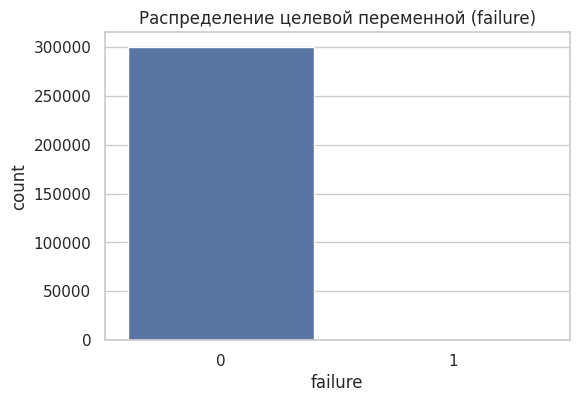

In [13]:
# График
plt.figure(figsize=(6,4))
sns.countplot(x='failure', data=df)
plt.title('Распределение целевой переменной (failure)')
plt.show()

In [14]:
failure_rate = df['failure'].mean()
failure_rate

np.float64(1e-05)

In [15]:
df[df['failure'] == 1]['serial_number'].nunique()

3

In [16]:
# Строки с отказом
df[df['failure'] == 1]

,date,serial_number,model,capacity_bytes,failure,datacenter,cluster_id,vault_id,pod_id,pod_slot_num,is_legacy_format,smart_1_normalized,smart_1_raw,smart_2_normalized,smart_2_raw,smart_3_normalized,smart_3_raw,smart_4_normalized,smart_4_raw,smart_5_normalized,smart_5_raw,smart_7_normalized,smart_7_raw,smart_8_normalized,smart_8_raw,smart_9_normalized,smart_9_raw,smart_10_normalized,smart_10_raw,smart_11_normalized,smart_11_raw,smart_12_normalized,smart_12_raw,smart_13_normalized,smart_13_raw,smart_15_normalized,smart_15_raw,smart_16_normalized,smart_16_raw,smart_17_normalized,smart_17_raw,smart_18_normalized,smart_18_raw,smart_22_normalized,smart_22_raw,smart_23_normalized,smart_23_raw,smart_24_normalized,smart_24_raw,smart_27_normalized,...,smart_220_normalized,smart_220_raw,smart_222_normalized,smart_222_raw,smart_223_normalized,smart_223_raw,smart_224_normalized,smart_224_raw,smart_225_normalized,smart_225_raw,smart_226_normalized,smart_226_raw,smart_230_normalized,smart_230_raw,smart_231_normalized,smart_231_raw,smart_232_normalized,smart_232_raw,smart_233_normalized,smart_233_raw,smart_234_normalized,smart_234_raw,smart_235_normalized,smart_235_raw,smart_240_normalized,smart_240_raw,smart_241_normalized,smart_241_raw,smart_242_normalized,smart_242_raw,smart_244_normalized,smart_244_raw,smart_245_normalized,smart_245_raw,smart_246_normalized,smart_246_raw,smart_247_normalized,smart_247_raw,smart_248_normalized,smart_248_raw,smart_250_normalized,smart_250_raw,smart_251_normalized,smart_251_raw,smart_252_normalized,smart_252_raw,smart_254_normalized,smart_254_raw,smart_255_normalized,smart_255_raw
1345491,2025-12-30,ZYD1MQQN,ST24000NM002H,24000277250048,1,iad1,50,1036,13,NaN,False,66.0,149044208.0,NaN,NaN,93.0,0.0,100.0,18.0,100.0,0.0,83.0,2.171132e+08,NaN,NaN,95.0,4939.0,100.0,0.0,NaN,NaN,100.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,4835.0,100.0,1.029661e+11,100.0,1.215485e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
348839,2025-12-28,ZA1407GG,ST8000NM0055,8001563222016,1,sac0,0,1038,19,NaN,False,53.0,114747368.0,NaN,NaN,89.0,0.0,100.0,12.0,100.0,2304.0,93.0,2.107192e+09,NaN,NaN,71.0,25667.0,100.0,0.0,NaN,NaN,100.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,25647.0,100.0,5.016676e+10,100.0,2.287333e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1685036,2025-12-31,ZYD1WDPL,ST24000NM002H,24000277250048,1,iad1,50,1036,13,NaN,False,76.0,202326641.0,NaN,NaN,92.0,0.0,100.0,19.0,100.0,0.0,87.0,5.438715e+08,NaN,NaN,95.0,4951.0,100.0,0.0,NaN,NaN,100.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,4918.0,100.0,1.274510e+11,100.0,1.576651e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# Наблюдений на один диск
df.groupby('serial_number').size().describe()

,0
count,210936.000000
mean,1.422232
std,0.638143
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,5.000000


### Вывод по целевой переменной

В рассматриваемом срезе данных наблюдается крайне сильный дисбаланс классов: всего 3 случая отказа на 300 000 наблюдений (доля порядка 1e-05).

Отказы относятся к 3 различным дискам, при этом в среднем на один диск приходится 1–2 наблюдения, что указывает на очень короткие временные ряды для отдельных устройств в выбранном срезе.

Такая структура данных означает:
- практически полное отсутствие представительности положительного класса
- невозможность корректного обучения модели на данном срезе без дополнительной агрегации данных
- высокий риск переобучения на единичных случаях отказа

При этом сами события отказа присутствуют, что позволяет использовать их для иллюстрации поведения SMART-параметров непосредственно перед отказом.

Таким образом, текущий срез данных подходит для первичного разведочного анализа и демонстрации временной динамики, однако для построения устойчивой модели потребуется значительно большее количество отказов, за более длительный период или по нескольким моделям дисков.



# 4. Выбор SMART признаков

In [19]:
selected_features = [
    'smart_1_raw',   # Raw Read Error Rate
    'smart_3_raw',   # Spin-Up Time
    'smart_4_raw',   # Start/Stop Count
    'smart_5_raw',   # Reallocated Sectors Count
    'smart_7_raw',   # Seek Error Rate
    'smart_9_raw',   # Power-On Hours
    'smart_187_raw', # Reported Uncorrectable Errors
    'smart_188_raw', # Command Timeout
    'smart_197_raw', # Current Pending Sector Count
    'smart_198_raw'  # Uncorrectable Sector Count
]

In [20]:
[f for f in selected_features if f in df.columns]

['smart_1_raw',
 'smart_3_raw',
 'smart_4_raw',
 'smart_5_raw',
 'smart_7_raw',
 'smart_9_raw',
 'smart_187_raw',
 'smart_188_raw',
 'smart_197_raw',
 'smart_198_raw']

In [21]:
df[selected_features].isna().mean().sort_values(ascending=False)

,0
smart_188_raw,0.666883
smart_187_raw,0.665717
smart_197_raw,0.025537
smart_3_raw,0.010310
smart_7_raw,0.010310
smart_4_raw,0.010310
smart_198_raw,0.007973
smart_5_raw,0.007050
smart_1_raw,0.002367
smart_9_raw,0.001443


In [22]:
selected_features = [
    'smart_1_raw',
    'smart_3_raw',
    'smart_4_raw',
    'smart_5_raw',
    'smart_7_raw',
    'smart_9_raw',
    'smart_197_raw',
    'smart_198_raw'
]

In [23]:
# Убираем признаки с > 60% пропусков
df_clean = df[selected_features + ['failure']].dropna()

In [24]:
df_clean.shape

(291713, 9)

### **Вывод по выбору признаков**

Анализ пропусков показал, что часть SMART-параметров содержит значительное количество отсутствующих значений более 60%, что делает их непригодными для использования в базовом анализе.

В результате были исключены признаки:
- smart_187_raw
- smart_188_raw

Оставшиеся признаки имеют низкую долю пропусков <3%, что позволяет использовать их без сложной предварительной обработки.

Для упрощения анализа строки с пропущенными значениями были удалены.

# 5. Анализ признаков

In [26]:
# Разделение данных
df_ok = df_clean[df_clean['failure'] == 0]
df_fail = df_clean[df_clean['failure'] == 1]

df_ok.shape, df_fail.shape

((291710, 9), (3, 9))

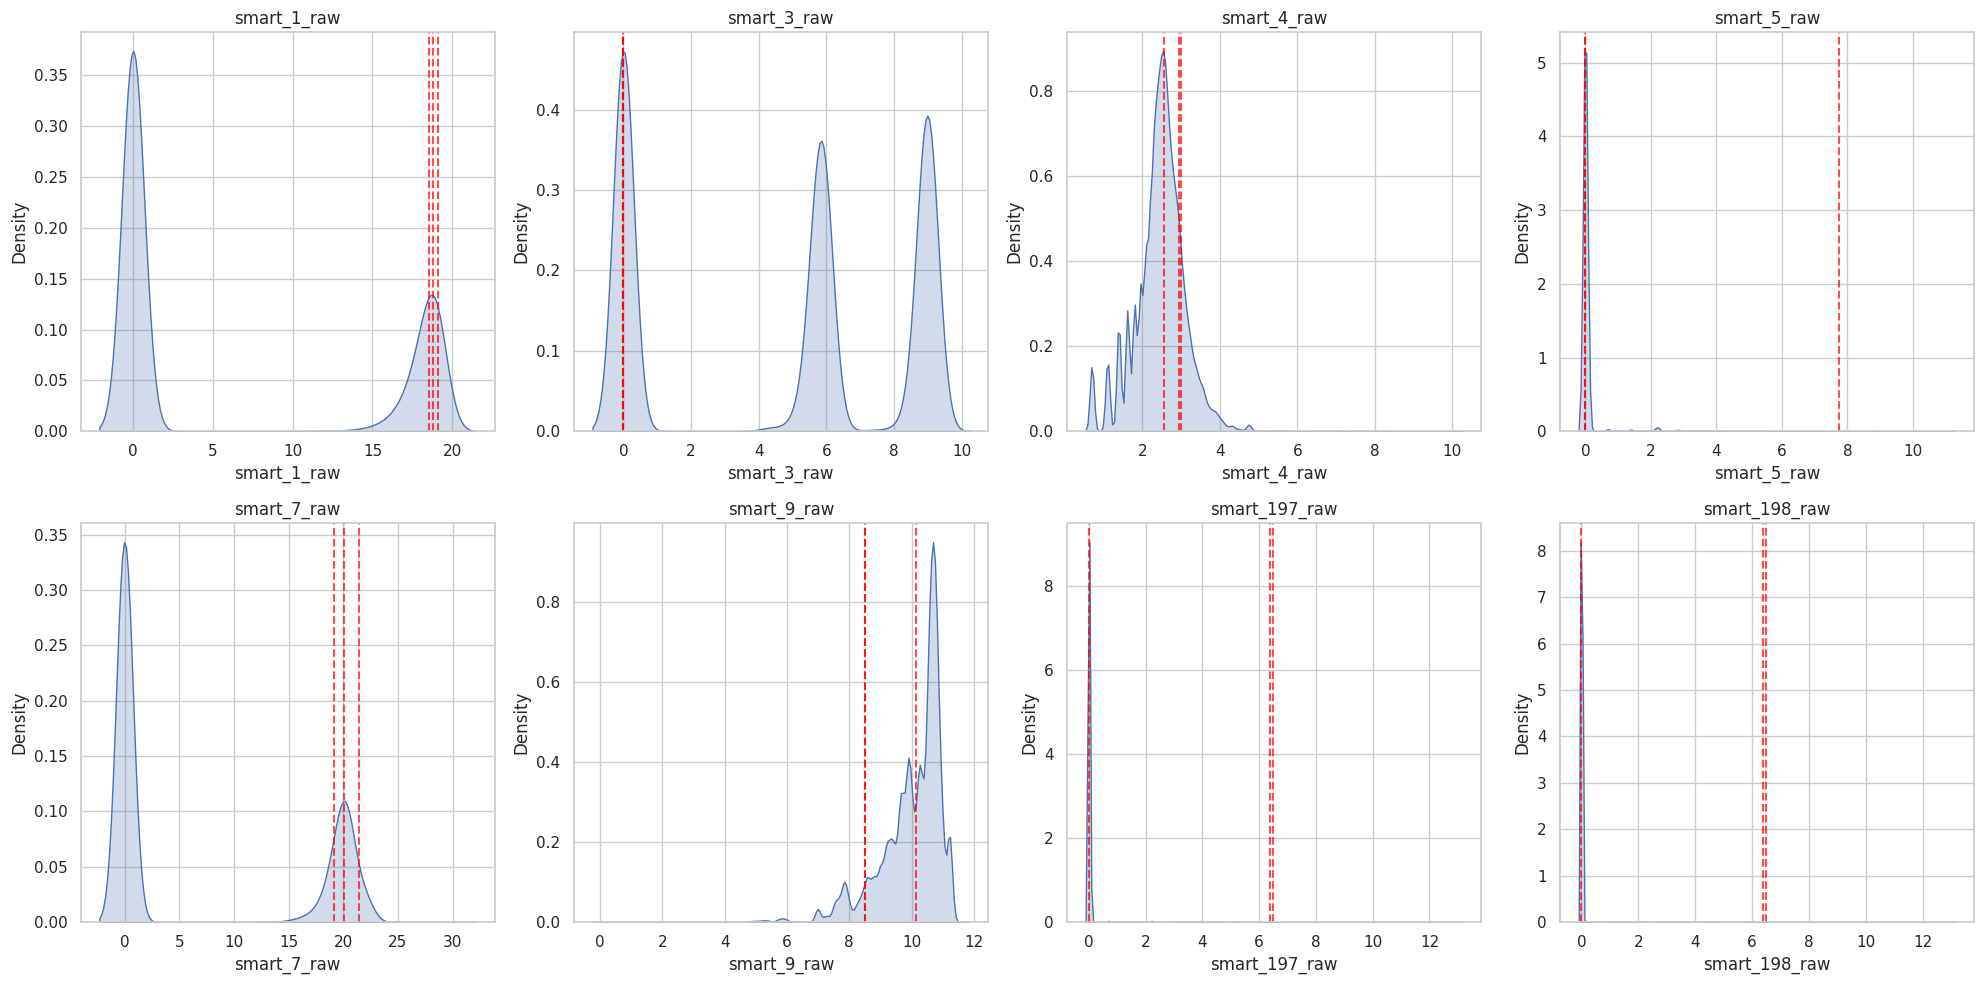

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

features = selected_features

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]

    # распределение нормальных
    sns.kdeplot(np.log1p(df_ok[feature]), ax=ax, fill=True)

    # точки отказов
    if len(df_fail) > 0:
        for val in df_fail[feature]:
            ax.axvline(np.log1p(val), color='red', linestyle='--', alpha=0.7)

    ax.set_title(feature)

plt.tight_layout()
plt.show()


### **Вывод по анализу SMART параметров**

Визуальный анализ распределений SMART-параметров с наложением значений отказов показывает наличие выраженных отклонений для ряда признаков.

**Наиболее заметные эффекты наблюдаются для:**

- smart_1_raw и smart_7_raw — значения отказавших дисков находятся значительно правее основной массы наблюдений, что указывает на аномально высокий уровень ошибок
- smart_9_raw — отказавшие диски имеют повышенные значения, что соответствует большему времени эксплуатации и накопленному износу
- smart_197_raw и smart_198_raw — значения для отказов существенно смещены вправо относительно нормального распределения, что указывает на наличие проблемных и неисправимых секторов

Для некоторых признаков (например, smart_3_raw, smart_4_raw) различия выражены слабее, и значения отказов находятся внутри основного распределения.

Таким образом, часть SMART-параметров демонстрирует четкий сигнал деградации перед отказом, что подтверждает их потенциальную информативность для задач предиктивного обслуживания.

При этом необходимо учитывать, что выводы сделаны на крайне ограниченном числе отказов, поэтому не носят статистически значимого характера

# 6. Временной анализ

In [29]:
failed_serials = df[df['failure'] == 1]['serial_number'].unique()
failed_serials

array(['ZYD1MQQN', 'ZA1407GG', 'ZYD1WDPL'], dtype=object)

In [34]:
serial = failed_serials[2]

df_disk = df[df['serial_number'] == serial].sort_values('date')
df_disk[['date', 'failure'] + selected_features]

,date,failure,smart_1_raw,smart_3_raw,smart_4_raw,smart_5_raw,smart_7_raw,smart_9_raw,smart_197_raw,smart_198_raw
329394,2025-12-27,0,55035344.0,0.0,18.0,0.0,517228400.0,4874.0,574.0,574.0
668411,2025-12-28,0,52499552.0,0.0,18.0,0.0,522019080.0,4890.0,576.0,576.0
1685036,2025-12-31,1,202326641.0,0.0,19.0,0.0,543871465.0,4951.0,586.0,586.0


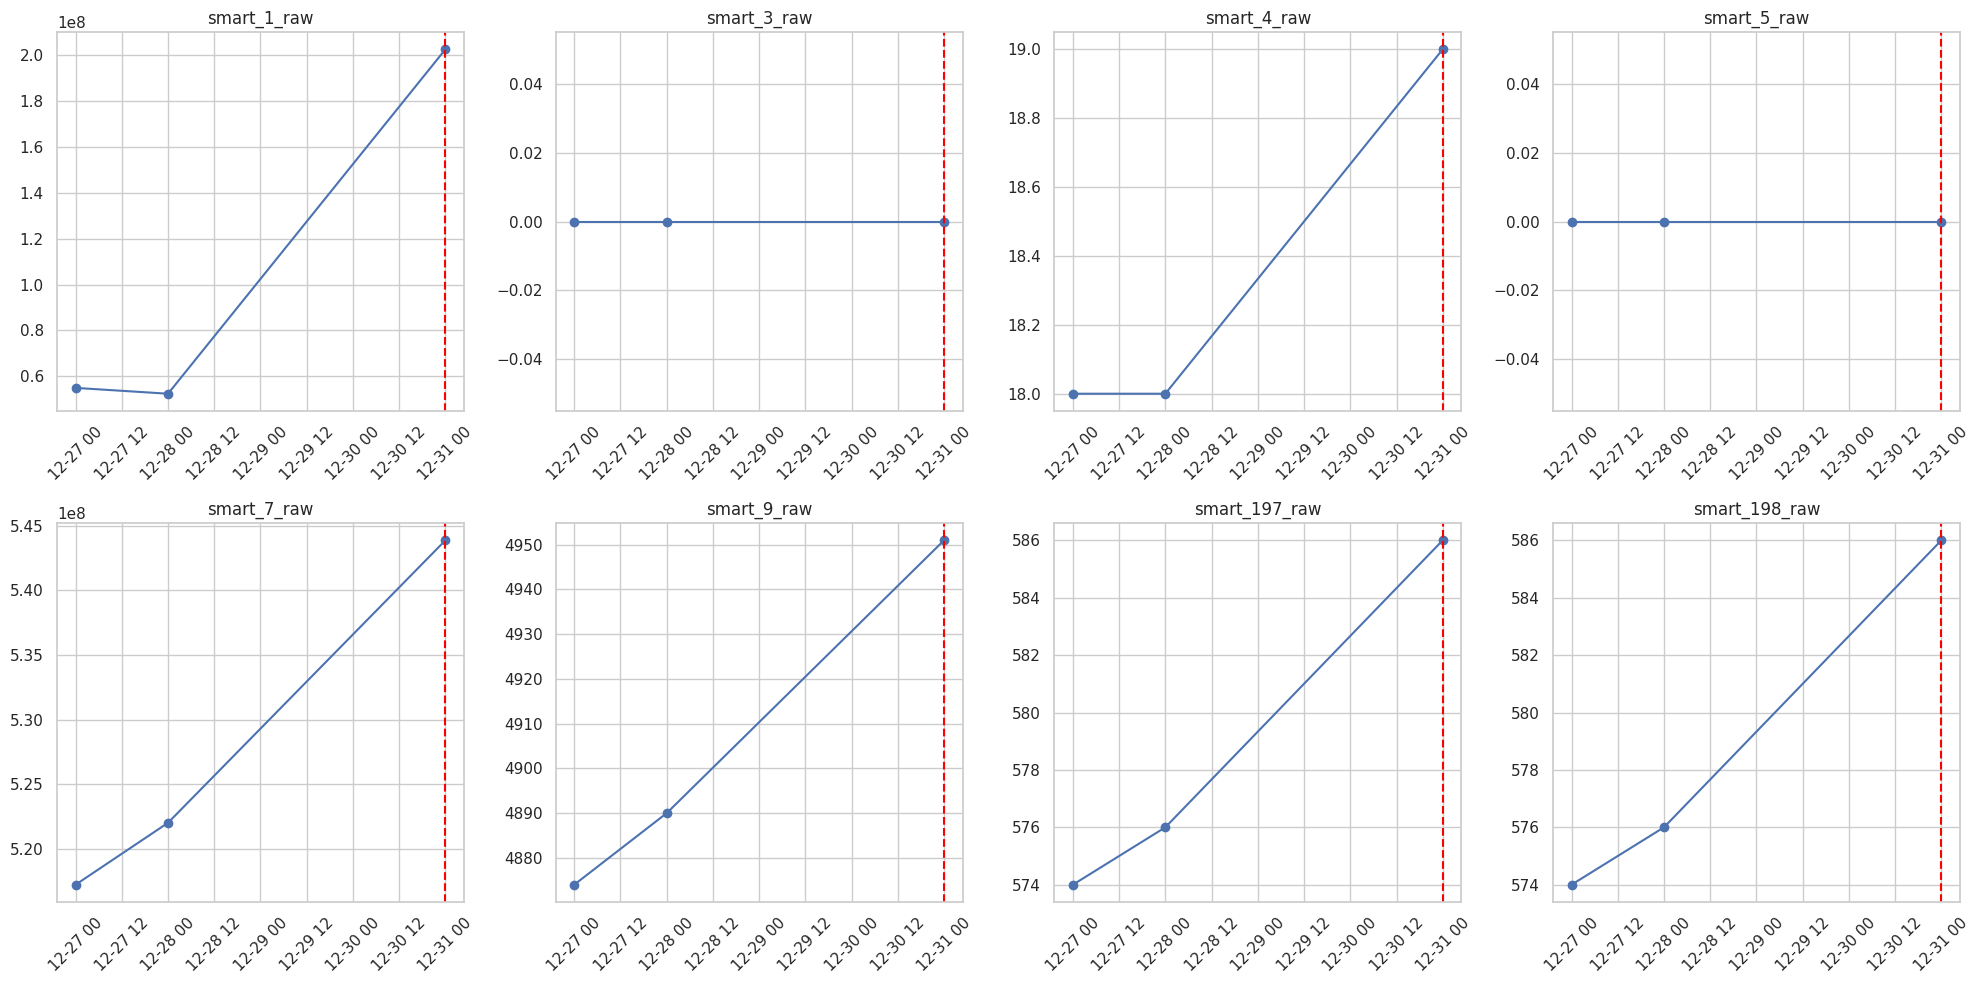

In [35]:
import matplotlib.pyplot as plt

features = selected_features

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]

    ax.plot(df_disk['date'], df_disk[feature], marker='o')

    # отмечаем момент отказа
    failure_dates = df_disk[df_disk['failure'] == 1]['date']
    for d in failure_dates:
        ax.axvline(d, color='red', linestyle='--')

    ax.set_title(feature)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### **Вывод по временному анализу**

Анализ временной динамики SMART-параметров для выбранного диска показывает постепенное изменение значений перед моментом отказа.

Для ряда признаков наблюдается выраженный рост значений:
- smart_1_raw и smart_7_raw демонстрируют значительное увеличение, что может указывать на рост ошибок чтения и позиционирования
- smart_9_raw время работы закономерно увеличивается, отражая накопленный износ
- smart_197_raw и smart_198_raw показывают рост количества проблемных и неисправимых секторов

При этом изменения происходят не скачкообразно, а последовательно от наблюдения к наблюдению, вероятно деградация перед отказом происходит постепенно.

Таким образом, даже на ограниченном числе наблюдений видно, что отказ сопровождается нарастающими аномалиями в SMART-параметрах, что делает возможным его прогнозирование при наличии более длинных временных рядов.

# 7. Пропуски

In [36]:
missing_ratio = df.isna().mean().sort_values(ascending=False)
missing_ratio.head(15)

,0
smart_164_raw,1.0
smart_160_normalized,1.0
smart_160_raw,1.0
smart_15_raw,1.0
smart_15_normalized,1.0
smart_161_raw,1.0
smart_161_normalized,1.0
smart_163_raw,1.0
smart_163_normalized,1.0
smart_164_normalized,1.0


In [37]:
df[selected_features].isna().mean()

,0
smart_1_raw,0.002367
smart_3_raw,0.010310
smart_4_raw,0.010310
smart_5_raw,0.007050
smart_7_raw,0.010310
smart_9_raw,0.001443
smart_197_raw,0.025537
smart_198_raw,0.007973


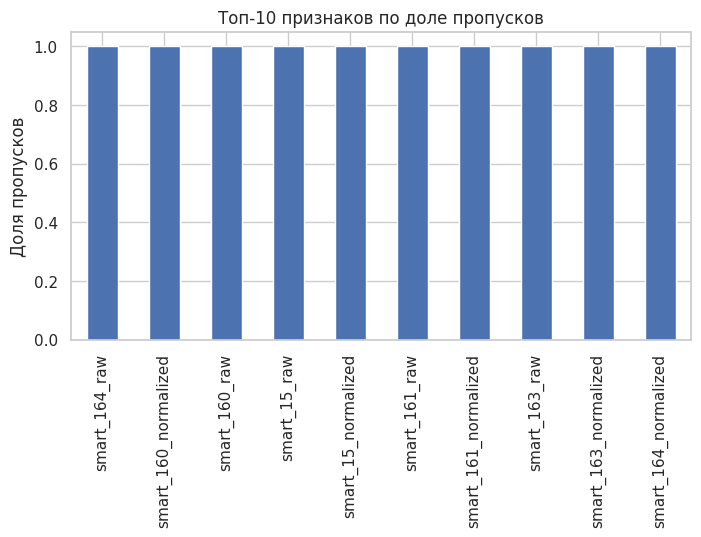

In [38]:
plt.figure(figsize=(8,4))
missing_ratio.head(10).plot(kind='bar')
plt.title('Топ-10 признаков по доле пропусков')
plt.ylabel('Доля пропусков')
plt.show()

### **Вывод по пропускам**

Анализ пропусков показал, что в датасете присутствует значительное количество отсутствующих значений, среди SMART-параметров.

Высокая доля пропусков для ряда признаков, например, smart_187_raw и smart_188_raw, обусловлена тем, что разные модели дисков поддерживают различные наборы SMART-метрик.

Для дальнейшего анализа были отобраны признаки с низкой долей пропусков <3%, что позволило избежать сложной обработки и сохранить репрезентативность данных.

Пропущенные значения в выбранных признаках были удалены, так как их доля незначительна и не оказывает существенного влияния на анализ.

# 8. Корреляции

In [39]:
corr = df_clean[selected_features].corr()
corr

,smart_1_raw,smart_3_raw,smart_4_raw,smart_5_raw,smart_7_raw,smart_9_raw,smart_197_raw,smart_198_raw
smart_1_raw,1.000000,-0.424679,0.021752,0.049315,0.014583,0.210093,0.005221,0.005992
smart_3_raw,-0.424679,1.000000,-0.020364,-0.029389,-0.011564,-0.115637,-0.003629,-0.002781
smart_4_raw,0.021752,-0.020364,1.000000,0.018671,0.000956,0.026899,-0.000260,-0.000262
smart_5_raw,0.049315,-0.029389,0.018671,1.000000,0.005866,0.048918,0.008869,0.008947
smart_7_raw,0.014583,-0.011564,0.000956,0.005866,1.000000,0.006561,0.000012,0.000032
smart_9_raw,0.210093,-0.115637,0.026899,0.048918,0.006561,1.000000,-0.001192,-0.001309
smart_197_raw,0.005221,-0.003629,-0.000260,0.008869,0.000012,-0.001192,1.000000,0.997047
smart_198_raw,0.005992,-0.002781,-0.000262,0.008947,0.000032,-0.001309,0.997047,1.000000


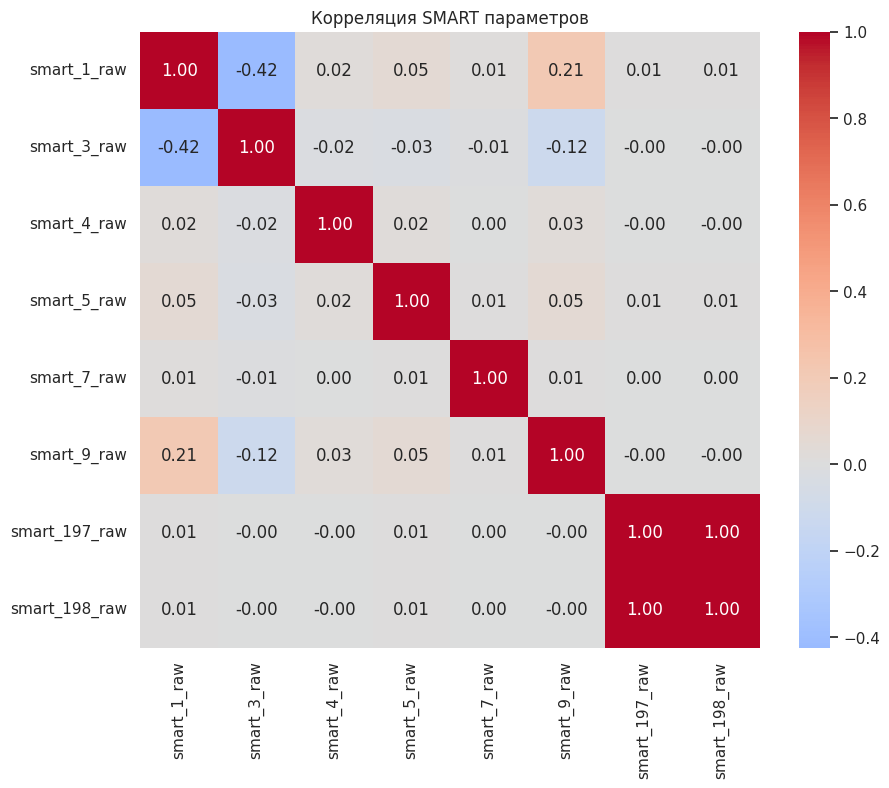

In [40]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляция SMART параметров")
plt.show()

### Вывод по корреляциям

Корреляционный анализ показал, что большинство выбранных SMART-параметров не коррелируют между собой, что указывает на их относительную независимость и потенциальную информативность в совокупности.

Исключением является пара признаков:
- smart_197_raw и smart_198_raw, которые имеют практически полную корреляцию ≈1.0, что объясняется их близкой физической природой - оба отражают состояние поврежденных секторов.

Также наблюдается умеренная отрицательная корреляция между:
- smart_1_raw и smart_3_raw

и слабая положительная зависимость:
- smart_1_raw и smart_9_raw

В целом, признаки не демонстрируют сильной мультиколлинеарности за исключением отдельных пар, что является положительным фактором для последующего моделирования.

Таким образом, выбранный набор признаков в целом информативен и не содержит избыточной зависимости, за исключением логически связанных параметров.

# 9. Выводы

## Итоговые выводы

В рамках работы был выполнен первичный разведочный анализ датасета Backblaze Hard Drive Stats на ограниченном временном срезе данных.

**По результатам анализа можно сделать следующие выводы:**

1. Датасет имеет выраженную временную структуру: каждая запись описывает состояние конкретного диска в конкретный день. Это делает его естественным кандидатом для задачи предсказания отказа.

2. Целевая переменная `failure` является крайне несбалансированной. В выбранном срезе обнаружено только 3 случая отказа на 300 000 наблюдений, поэтому текущий набор данных недостаточен для полноценного обучения устойчивой модели.

3. Несмотря на малое число отказов, ряд SMART-параметров демонстрирует осмысленный сигнал:
   - признаки, связанные с ошибками чтения и позиционирования
   - признаки, связанные с поврежденными и неисправимыми секторами
   - признаки, отражающие накопленный износ

4. Визуальный анализ показал, что некоторые значения отказавших дисков находятся в хвостах распределений, а временной анализ выявил постепенное изменение части параметров перед отказом. Это согласуется с гипотезой о постепенной деградации диска до момента отказа.

5. Анализ пропусков показал, что датасет неоднороден: разные модели дисков поддерживают разные наборы SMART-метрик. Следовательно, для построения модели потребуется более аккуратная стратегия отбора признаков и, вероятно, сегментация по моделям дисков.

6. Корреляционный анализ показал, что большинство выбранных признаков не являются сильно зависимыми друг от друга, за исключением отдельных логически связанных пар.

Таким образом, текущий анализ подтверждает, что датасет подходит для задачи прогнозирования отказов, но в текущем срезе он пригоден прежде всего для первичного EDA и демонстрации наличия сигнала, а не для финального моделирования.

## **Перспективы и следующий этап работы**

Текущий анализ является первичным и имеет демонстрационный характер. Для построения полноценного решения в рамках MLOps проекта необходим следующий этап углубления данных и постановки задачи.

### Что необходимо сделать дальше

**1. Расширить временной горизонт данных**  
Использовать не несколько дней, а существенно более длинный период наблюдений, например несколько месяцев или полный год. Это позволит получить значительно больше случаев отказов и построить более репрезентативную выборку.

**2. Переформулировать задачу более практично**  
Вместо предсказания `failure = 1` в конкретный день целесообразно перейти к задаче раннего предупреждения:
- отказ в течение ближайших N дней
- выявление дисков в зоне повышенного риска

**3. Построить признаки на основе временной динамики**  
Для практической модели недостаточно использовать необходимо добавить:
- приросты признаков
- скользящие средние
- скорость изменения параметров
- число дней до отказа

Именно такие признаки будут лучше отражать деградацию оборудования.

**4. Выполнить анализ по моделям дисков отдельно**  
Разные модели дисков могут иметь разный профиль SMART-метрик и разную природу отказов. Поэтому вероятно:
- либо ограничиться одной моделью
- либо строить модельные сегменты
- либо добавлять модель диска как важный категориальный признак

**5. Корректно обработать дисбаланс классов**  
Поскольку отказы редки, необходимо использовать:
- временное ресемплирование
- метрики: ROC-AUC, PR-AUC, recall, F1

**6. Провести отбор признаков и моделирование байзлайна**  
Следующим практическим этапом должны стать:
- обучение baseline-моделей
- оценка значимости признаков
- сравнение метрик
- проверка устойчивости модели на временном ряде

**7. Подготовить MLOps-контур**  

_______________________________

### **Практический вывод**

На текущем этапе работа показывает, что датасет действительно содержит полезный сигнал для прогнозирования отказов. Однако для реальной модели требуется перейти от короткого демонстрационного среза к длинным временным рядам, более корректной целевой постановке и полноценному инженерному пайплайну обработки данных.